## Imports and configuration

In [7]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    classification_report,
)

DATA_XLSX_PATH = Path("omop_mimic_data.xlsx")
MAPPING_JSON_PATH = Path("mapping_report_llama.json")

OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATASET_DIR = OUTPUT_DIR / "datasets_per_threshold"

for d in (OUTPUT_DIR, FIG_DIR, TABLE_DIR, DATASET_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Confidence-threshold grid swept over both mapping levels
THRESHOLDS = np.round(np.arange(0.45, 1.00, 0.05), 2)

# Aliases used by the mapping pipeline for some MIMIC tables
TABLE_ALIASES = {
    "admissions_items": "admissions",
    "diagnoses_icd_items": "diagnoses_icd",
    "procedures_icd_items": "procedures_icd",
    "prescriptions_items": "prescriptions",
    "labevents_items": "labevents",
    "microbiologyevents_items": "microbiologyevents",
    "inputevents_items": "inputevents",
    "outputevents_items": "outputevents",
    "datetimeevents_items": "datetimeevents",
    "chartevents_items": "chartevents",
    "d_icd_diagnoses_items": "d_icd_diagnoses",
    "d_labitems_items": "d_labitems",
}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 80)

print("Output directory:", OUTPUT_DIR.resolve())
print("Thresholds:", THRESHOLDS)

Output directory: D:\memoire\rag\1.0.0\evaluation\llama_eval\outputs
Thresholds: [0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95]


## 1. Column-level evaluation

In [8]:
origin_column = pd.read_excel(DATA_XLSX_PATH)
origin_column = origin_column.rename(columns={"label": "label_origin"})
origin_column["omop_table_name"] = origin_column["omop"].str.split("-", n=1).str[0]
origin_column["mimic_table_name"] = origin_column["table"].str.split("-", n=1).str[0]

print("Universe size (OMOP attribute x MIMIC column pairs):", origin_column.shape)
print("Unique OMOP attributes:", origin_column["omop"].nunique())
print("Unique MIMIC columns:", origin_column["table"].nunique())
print("Gold positive pairs:", int(origin_column["label_origin"].sum()))

display(origin_column.head(3))

Universe size (OMOP attribute x MIMIC column pairs): (64080, 11)
Unique OMOP attributes: 267
Unique MIMIC columns: 240
Gold positive pairs: 129


,omop,table,des1,des2,label_origin,d1,d2,d3,d4,omop_table_name,mimic_table_name
0,person-person_id,admissions-mimic_id,the person domain contains records that uniquely identify each patient in th...,the admissions table gives information regarding a patient’s admission to th...,0,the person domain contains records that uniquely identify each patient in th...,a unique identifier for each person.,the admissions table gives information regarding a patient’s admission to th...,a unique id for all mimic tables.,person,admissions
1,person-person_id,admissions-hadm_id,the person domain contains records that uniquely identify each patient in th...,the admissions table gives information regarding a patient’s admission to th...,0,the person domain contains records that uniquely identify each patient in th...,a unique identifier for each person.,the admissions table gives information regarding a patient’s admission to th...,hadm_id represents a single patient’s admission to the hospital.,person,admissions
2,person-person_id,admissions-admittime,the person domain contains records that uniquely identify each patient in th...,the admissions table gives information regarding a patient’s admission to th...,0,the person domain contains records that uniquely identify each patient in th...,a unique identifier for each person.,the admissions table gives information regarding a patient’s admission to th...,admittime provides the date and time the patient was admitted to the hospital.,person,admissions


In [9]:
raw_mapping = json.load(open(MAPPING_JSON_PATH))

attr_rows = []
for entity in raw_mapping["mapping"]:
    matched_table = TABLE_ALIASES.get(entity["matched_table"], entity["matched_table"])
    for attr in entity["attributes"]:
        target_column = attr["target_column"]
        attr_rows.append({
            "omop_key": f"{entity['entity']}-{attr['name']}",
            "predicted_omop_table": entity["entity"],
            "predicted_mimic_table": matched_table,
            "predicted_table_confidence": entity["table_confidence"],
            "predicted_table_key": f"{matched_table}-{target_column}" if target_column is not None else None,
            "predicted_column_confidence": attr["confidence"],
        })

column_predictions = pd.DataFrame(attr_rows).drop_duplicates(subset=["omop_key"])

n_no_target = column_predictions["predicted_table_key"].isna().sum()
print("Attributes covered by the model:", len(column_predictions))
print("Attributes for which the model predicted no target column:", n_no_target)

display(column_predictions.head(5))

Attributes covered by the model: 267
Attributes for which the model predicted no target column: 167


,omop_key,predicted_omop_table,predicted_mimic_table,predicted_table_confidence,predicted_table_key,predicted_column_confidence
0,person-birth_datetime,person,patients,0.74992,patients-dob,0.68600
1,person-care_site_id,person,patients,0.74992,patients-patients_id,0.69292
2,person-day_of_birth,person,patients,0.74992,NaN,0.63896
3,person-death_datetime,person,patients,0.74992,NaN,0.67800
4,person-ethnicity_concept_id,person,patients,0.74992,NaN,0.61636


In [10]:
column_merged = origin_column.merge(
    column_predictions, left_on="omop", right_on="omop_key", how="left"
)

is_selected_pair = column_merged["table"] == column_merged["predicted_table_key"]
column_merged["match_confidence"] = np.where(
    is_selected_pair, column_merged["predicted_column_confidence"], np.nan
)

n_hallucinated = column_predictions["predicted_table_key"].notna().sum() - is_selected_pair.sum()
print("Model predictions that land on a real universe pair:", int(is_selected_pair.sum()))
print("Model predictions pointing to a column outside the candidate universe:", int(n_hallucinated))

Model predictions that land on a real universe pair: 38
Model predictions pointing to a column outside the candidate universe: 62


In [11]:
def build_labeled_dataset(merged_df, threshold, confidence_col="match_confidence"):
    df = merged_df.drop(
        columns=[c for c in merged_df.columns if c.startswith("predicted_") or c == "omop_key"]
    ).copy()
    df["label"] = (df[confidence_col].fillna(-1) >= threshold).astype(int)
    return df


def evaluate_against_origin(df, threshold, label_col="label", origin_col="label_origin"):
    y_true = df[origin_col].astype(int).to_numpy()
    y_pred = df[label_col].astype(int).to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


column_threshold_datasets = {}
column_results = []

for threshold in THRESHOLDS:
    dataset = build_labeled_dataset(column_merged, threshold)
    column_threshold_datasets[threshold] = dataset
    dataset.to_csv(DATASET_DIR / f"column_dataset_thr_{threshold:.2f}.csv", index=False)
    column_results.append(evaluate_against_origin(dataset, threshold))

column_results_df = pd.DataFrame(column_results)
column_results_df.to_csv(TABLE_DIR / "column_results.csv", index=False)

display(
    column_results_df.style.format({
        c: "{:.4f}" for c in ["accuracy", "precision", "recall", "f1", "balanced_accuracy", "mcc"]
    })
)

,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TP,FP,FN,TN
0,0.450000,0.9975,0.1316,0.0388,0.0599,0.5191,0.0704,5,33,124,63918
1,0.500000,0.9975,0.1316,0.0388,0.0599,0.5191,0.0704,5,33,124,63918
2,0.550000,0.9975,0.1316,0.0388,0.0599,0.5191,0.0704,5,33,124,63918
3,0.600000,0.9975,0.1316,0.0388,0.0599,0.5191,0.0704,5,33,124,63918
4,0.650000,0.9975,0.1316,0.0388,0.0599,0.5191,0.0704,5,33,124,63918
5,0.700000,0.9978,0.1739,0.0310,0.0526,0.5154,0.0727,4,19,125,63932
6,0.750000,0.9980,0.0000,0.0000,0.0000,0.5000,-0.0002,0,1,129,63950
7,0.800000,0.9980,0.0000,0.0000,0.0000,0.5000,-0.0002,0,1,129,63950
8,0.850000,0.9980,0.0000,0.0000,0.0000,0.5000,-0.0002,0,1,129,63950
9,0.900000,0.9980,0.0000,0.0000,0.0000,0.5000,-0.0002,0,1,129,63950


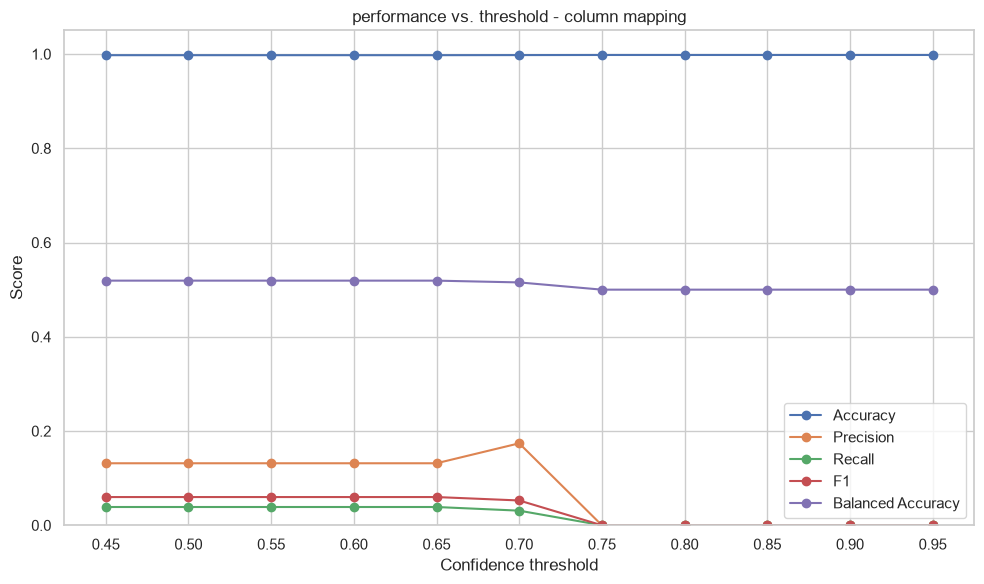

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for metric in ["accuracy", "precision", "recall", "f1", "balanced_accuracy"]:
    ax.plot(column_results_df["threshold"], column_results_df[metric], marker="o", label=metric.replace("_", " ").title())

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Score")
ax.set_title("performance vs. threshold - column mapping")
ax.set_ylim(0, 1.05)
ax.set_xticks(THRESHOLDS)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_column_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

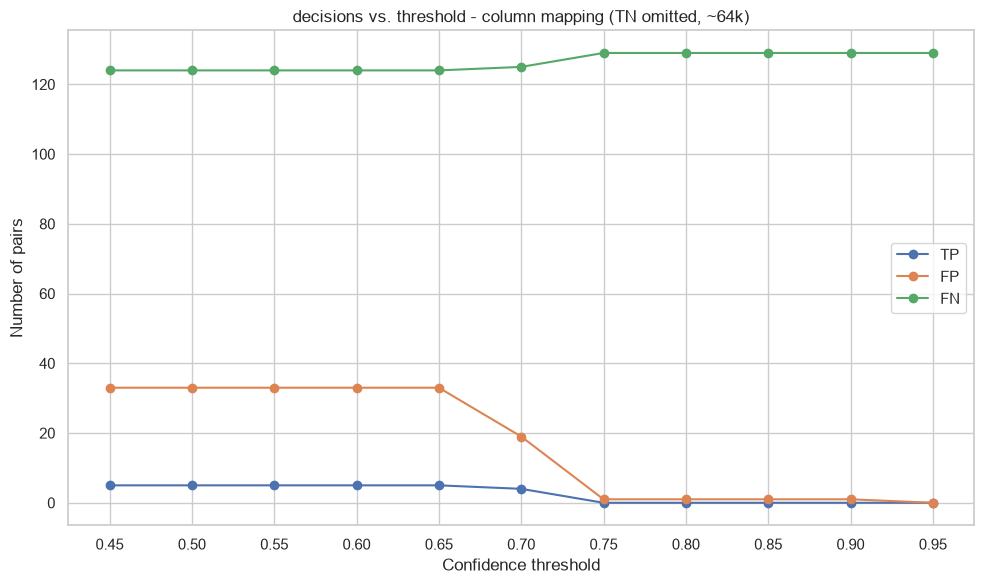

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
for metric in ["TP", "FP", "FN"]:
    ax.plot(column_results_df["threshold"], column_results_df[metric], marker="o", label=metric)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Number of pairs")
ax.set_title("decisions vs. threshold - column mapping (TN omitted, ~64k)")
ax.set_xticks(THRESHOLDS)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_column_counts.png", dpi=300, bbox_inches="tight")
plt.show()

Best column threshold (max F1): 0.45


,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TP,FP,FN,TN
0,0.45,0.99755,0.131579,0.03876,0.05988,0.519122,0.070413,5.0,33.0,124.0,63918.0


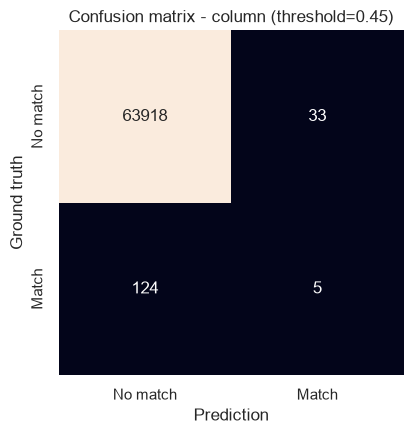

,precision,recall,f1-score,support
No match,0.998064,0.999484,0.998773,63951.00000
Match,0.131579,0.038760,0.059880,129.00000
accuracy,0.997550,0.997550,0.997550,0.99755
macro avg,0.564821,0.519122,0.529327,64080.00000
weighted avg,0.996319,0.997550,0.996883,64080.00000


In [14]:
best_column_row = column_results_df.loc[column_results_df["f1"].idxmax()]
best_column_threshold = float(best_column_row["threshold"])
print(f"Best column threshold (max F1): {best_column_threshold:.2f}")
display(best_column_row.to_frame().T)

best_column_dataset = column_threshold_datasets[best_column_threshold]

cm = confusion_matrix(
    best_column_dataset["label_origin"].astype(int),
    best_column_dataset["label"].astype(int),
    labels=[0, 1],
)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", square=True, cbar=False,
            xticklabels=["No match", "Match"], yticklabels=["No match", "Match"], ax=ax)
ax.set_xlabel("Prediction")
ax.set_ylabel("Ground truth")
ax.set_title(f"Confusion matrix - column (threshold={best_column_threshold:.2f})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_column_best_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

column_report = pd.DataFrame(
    classification_report(
        best_column_dataset["label_origin"].astype(int),
        best_column_dataset["label"].astype(int),
        target_names=["No match", "Match"],
        zero_division=0,
        output_dict=True,
    )
).T
display(column_report)
column_report.to_csv(TABLE_DIR / "column_best_classification_report.csv")

In [15]:
def fine_threshold_search(merged_df, confidence_col="match_confidence", origin_col="label_origin"):
    observed = merged_df[confidence_col].dropna().unique()
    observed = np.sort(observed)
    midpoints = (observed[:-1] + observed[1:]) / 2
    candidates = np.concatenate(([observed.min() - 1e-6], midpoints, [observed.max() + 1e-6]))

    rows = []
    for threshold in candidates:
        dataset = build_labeled_dataset(merged_df, threshold, confidence_col)
        rows.append(evaluate_against_origin(dataset, threshold))
    return pd.DataFrame(rows)


column_fine_results = fine_threshold_search(column_merged)
column_fine_results.to_csv(TABLE_DIR / "column_fine_results.csv", index=False)

column_fine_best = column_fine_results.loc[column_fine_results["f1"].idxmax()]
print(f"Fine-grained optimal threshold (max F1) - columns: {column_fine_best['threshold']:.4f}")
display(column_fine_best.to_frame().T)

Fine-grained optimal threshold (max F1) - columns: 0.6855


,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TP,FP,FN,TN
5,0.68554,0.997628,0.151515,0.03876,0.061728,0.519161,0.075711,5.0,28.0,124.0,63923.0


## 2. Table-level evaluation

In [16]:
omop_tables = sorted(origin_column["omop_table_name"].unique())
mimic_tables = sorted(origin_column["mimic_table_name"].unique())

gold_table_pairs = set(
    origin_column.loc[origin_column["label_origin"] == 1, ["omop_table_name", "mimic_table_name"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

origin_table = pd.MultiIndex.from_product(
    [omop_tables, mimic_tables], names=["omop_table", "mimic_table"]
).to_frame(index=False)
origin_table["label_origin"] = origin_table.apply(
    lambda r: int((r["omop_table"], r["mimic_table"]) in gold_table_pairs), axis=1
)

print("Table-level universe size:", origin_table.shape)
print("Gold positive table pairs:", int(origin_table["label_origin"].sum()))
display(origin_table.head(3))

Table-level universe size: (525, 3)
Gold positive table pairs: 46


,omop_table,mimic_table,label_origin
0,care_site,admissions,0
1,care_site,callout,0
2,care_site,caregivers,0


In [17]:
table_predictions = column_predictions[
    ["predicted_omop_table", "predicted_mimic_table", "predicted_table_confidence"]
].drop_duplicates(subset=["predicted_omop_table"])

table_merged = origin_table.merge(
    table_predictions,
    left_on="omop_table", right_on="predicted_omop_table",
    how="left",
)

is_selected_table_pair = table_merged["mimic_table"] == table_merged["predicted_mimic_table"]
table_merged["match_confidence"] = np.where(
    is_selected_table_pair, table_merged["predicted_table_confidence"], np.nan
)

n_hallucinated_tables = table_predictions["predicted_mimic_table"].isin(mimic_tables).eq(False).sum()
print("Predicted MIMIC tables outside the candidate universe:", int(n_hallucinated_tables))

Predicted MIMIC tables outside the candidate universe: 4


In [18]:
table_threshold_datasets = {}
table_results = []

for threshold in THRESHOLDS:
    dataset = build_labeled_dataset(table_merged, threshold)
    table_threshold_datasets[threshold] = dataset
    dataset.to_csv(DATASET_DIR / f"table_dataset_thr_{threshold:.2f}.csv", index=False)
    table_results.append(evaluate_against_origin(dataset, threshold))

table_results_df = pd.DataFrame(table_results)
table_results_df.to_csv(TABLE_DIR / "table_results.csv", index=False)

display(
    table_results_df.style.format({
        c: "{:.4f}" for c in ["accuracy", "precision", "recall", "f1", "balanced_accuracy", "mcc"]
    })
)

,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TP,FP,FN,TN
0,0.450000,0.8914,0.1765,0.0652,0.0952,0.5180,0.0575,3,14,43,465
1,0.500000,0.8914,0.1765,0.0652,0.0952,0.5180,0.0575,3,14,43,465
2,0.550000,0.8914,0.1765,0.0652,0.0952,0.5180,0.0575,3,14,43,465
3,0.600000,0.8914,0.1765,0.0652,0.0952,0.5180,0.0575,3,14,43,465
4,0.650000,0.8952,0.2000,0.0652,0.0984,0.5201,0.0682,3,12,43,467
5,0.700000,0.8990,0.2308,0.0652,0.1017,0.5222,0.0807,3,10,43,469
6,0.750000,0.9105,0.3333,0.0217,0.0408,0.5088,0.0659,1,2,45,477
7,0.800000,0.9124,0.0000,0.0000,0.0000,0.5000,0.0000,0,0,46,479
8,0.850000,0.9124,0.0000,0.0000,0.0000,0.5000,0.0000,0,0,46,479
9,0.900000,0.9124,0.0000,0.0000,0.0000,0.5000,0.0000,0,0,46,479


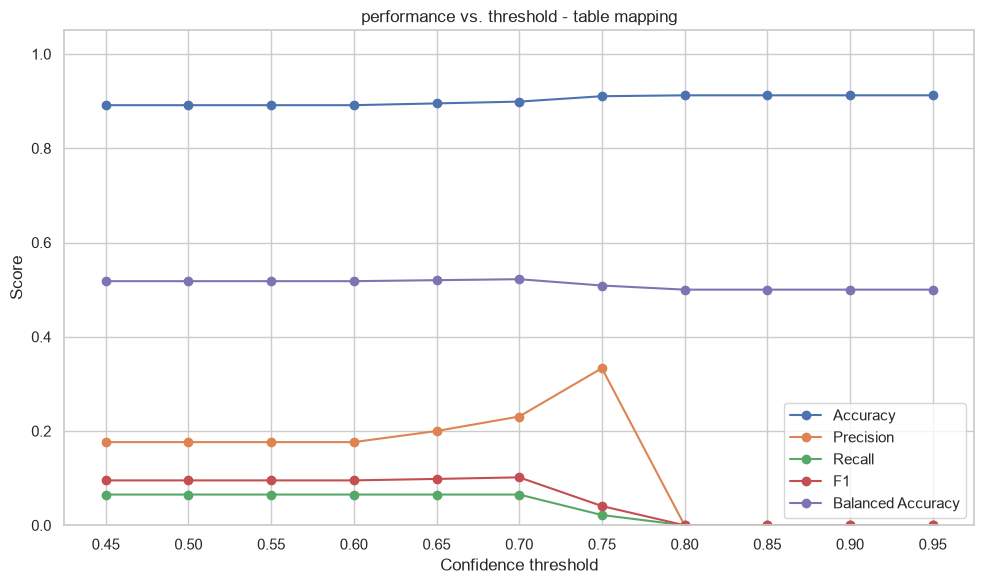

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
for metric in ["accuracy", "precision", "recall", "f1", "balanced_accuracy"]:
    ax.plot(table_results_df["threshold"], table_results_df[metric], marker="o", label=metric.replace("_", " ").title())

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Score")
ax.set_title("performance vs. threshold - table mapping")
ax.set_ylim(0, 1.05)
ax.set_xticks(THRESHOLDS)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_table_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

Best table threshold (max F1): 0.70


,threshold,accuracy,precision,recall,f1,balanced_accuracy,mcc,TP,FP,FN,TN
5,0.7,0.899048,0.230769,0.065217,0.101695,0.52217,0.080675,3.0,10.0,43.0,469.0


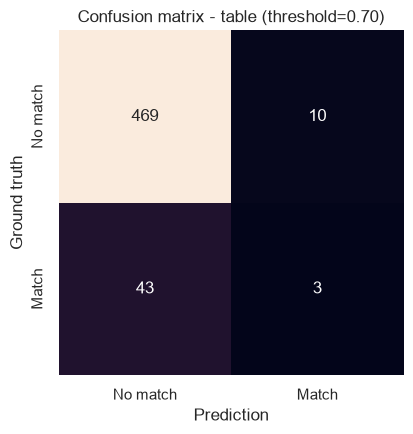

In [20]:
best_table_row = table_results_df.loc[table_results_df["f1"].idxmax()]
best_table_threshold = float(best_table_row["threshold"])
print(f"Best table threshold (max F1): {best_table_threshold:.2f}")
display(best_table_row.to_frame().T)

best_table_dataset = table_threshold_datasets[best_table_threshold]

cm = confusion_matrix(
    best_table_dataset["label_origin"].astype(int),
    best_table_dataset["label"].astype(int),
    labels=[0, 1],
)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", square=True, cbar=False,
            xticklabels=["No match", "Match"], yticklabels=["No match", "Match"], ax=ax)
ax.set_xlabel("Prediction")
ax.set_ylabel("Ground truth")
ax.set_title(f"Confusion matrix - table (threshold={best_table_threshold:.2f})")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig05_table_best_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
open_world_column = column_merged[column_merged["match_confidence"].notna()].copy()
open_world_column["label"] = 1 
open_world_precision_at_best = precision_score(
    open_world_column["label_origin"].astype(int), open_world_column["label"], zero_division=0
)
open_world_recall_note = (
    "Not meaningful for a single fixed set of proposals without a threshold sweep on "
    "confidence within the proposed subset; see evaluation_optimized.ipynb for that version."
)

comparison = pd.DataFrame([
    {
        "Evaluation": "(this notebook)",
        "Universe size": len(column_merged),
        "Recall @ best F1 threshold": best_column_row["recall"],
        "Precision @ best F1 threshold": best_column_row["precision"],
        "F1 @ best F1 threshold": best_column_row["f1"],
    },
    {
        "Evaluation": "Open-world (predicted pairs only)",
        "Universe size": len(open_world_column),
        "Recall @ best F1 threshold": np.nan,
        "Precision @ best F1 threshold": open_world_precision_at_best,
        "F1 @ best F1 threshold": np.nan,
    },
])

display(comparison)
comparison.to_csv(TABLE_DIR / " data_comparison.csv", index=False)

print(
    "Recall computed over the full universe accounts for every OMOP attribute the model "
    "never matched to its correct column at all - this is why recall is "
    "typically much lower than an open-world evaluation restricted to the model's own shortlist."
)

,Evaluation,Universe size,Recall @ best F1 threshold,Precision @ best F1 threshold,F1 @ best F1 threshold
0,(this notebook),64080,0.03876,0.131579,0.05988
1,Open-world (predicted pairs only),38,NaN,0.131579,NaN


Recall computed over the full universe accounts for every OMOP attribute the model never matched to its correct column at all - this is why recall is typically much lower than an open-world evaluation restricted to the model's own shortlist.


## 4. Final summary

In [22]:
final_summary = {
    "column_universe_size": len(column_merged),
    "column_gold_positives": int(origin_column["label_origin"].sum()),
    "column_best_threshold": best_column_threshold,
    "column_best_f1": float(best_column_row["f1"]),
    "column_best_precision": float(best_column_row["precision"]),
    "column_best_recall": float(best_column_row["recall"]),
    "table_universe_size": len(table_merged),
    "table_gold_positives": int(origin_table["label_origin"].sum()),
    "table_best_threshold": best_table_threshold,
    "table_best_f1": float(best_table_row["f1"]),
    "table_best_precision": float(best_table_row["precision"]),
    "table_best_recall": float(best_table_row["recall"]),
}

final_summary_df = pd.DataFrame(list(final_summary.items()), columns=["Metric", "Value"])
display(final_summary_df)
final_summary_df.to_csv(TABLE_DIR / "final_summary.csv", index=False)

print("\nevaluation complete.")
print("Per-threshold datasets:", DATASET_DIR.resolve())
print("Figures:", FIG_DIR.resolve())
print("Tables:", TABLE_DIR.resolve())

,Metric,Value
0,column_universe_size,64080.000000
1,column_gold_positives,129.000000
2,column_best_threshold,0.450000
3,column_best_f1,0.059880
4,column_best_precision,0.131579
5,column_best_recall,0.038760
6,table_universe_size,525.000000
7,table_gold_positives,46.000000
8,table_best_threshold,0.700000
9,table_best_f1,0.101695



evaluation complete.
Per-threshold datasets: D:\memoire\rag\1.0.0\evaluation\llama_eval\outputs\datasets_per_threshold
Figures: D:\memoire\rag\1.0.0\evaluation\llama_eval\outputs\figures
Tables: D:\memoire\rag\1.0.0\evaluation\llama_eval\outputs\tables
